# OBTAIN STAGE 

In [1]:
import os
import zipfile
import pandas as pd
from tqdm import tqdm

In [3]:
# List the zip's contents without extracting anything yet
zip_path = "../data/raw/FakeAVCeleb_v1.2.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    all_files = zip_ref.namelist()

print(f"Total files in zip: {len(all_files)}")
print("\nFirst 20 entries:")
for f in all_files[:20]:
    print(" -", f)

Total files in zip: 24110

First 20 entries:
 - FakeAVCeleb_v1.2/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id00476_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01076_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01179_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id02005_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id02342_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00518_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00761_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00987_wavtolip.mp4
 - FakeAVC

In [4]:
# Search for any CSV/metadata files
meta_candidates = [f for f in all_files if f.lower().endswith('.csv') or 'meta' in f.lower()]
print("Metadata candidates found:")
for f in meta_candidates:
    print(" -", f)

# Also inspect the top-level category folders
top_level = sorted(set(f.split('/')[1] for f in all_files if '/' in f and len(f.split('/')) > 1))
print("\nTop-level categories:")
for t in top_level:
    print(" -", t)

Metadata candidates found:
 - FakeAVCeleb_v1.2/meta_data.csv

Top-level categories:
 - 
 - FakeVideo-FakeAudio
 - FakeVideo-RealAudio
 - README.txt
 - RealVideo-FakeAudio
 - RealVideo-RealAudio
 - meta_data.csv


In [5]:
#Extract just the metadata CSV and README (tiny, safe)
small_files = ["FakeAVCeleb_v1.2/meta_data.csv", "FakeAVCeleb_v1.2/README.txt"]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for f in small_files:
        zip_ref.extract(f, path="../data/raw/")

print("Extracted:", small_files)

Extracted: ['FakeAVCeleb_v1.2/meta_data.csv', 'FakeAVCeleb_v1.2/README.txt']


In [6]:
df = pd.read_csv("../data/raw/FakeAVCeleb_v1.2/meta_data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(21566, 10)
['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']


,source,target1,target2,method,category,type,race,gender,path,Unnamed: 9
0,id00076,-,-,real,A,RealVideo-RealAudio,African,men,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
1,id00166,-,-,real,A,RealVideo-RealAudio,African,men,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
2,id00173,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
3,id00366,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
4,id00391,-,-,real,A,RealVideo-RealAudio,African,men,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...


In [7]:
# See the full, untruncated content of a few rows, especially the path columns
pd.set_option('display.max_colwidth', None)
print(df[['path', 'Unnamed: 9']].head(10))

# Distribution across type (our main label)
print("\n--- type ---")
print(df['type'].value_counts())

# Distribution across category (short code)
print("\n--- category ---")
print(df['category'].value_counts())

# Distribution across race and gender (relevant for balanced sampling + your Ethics Statement)
print("\n--- race ---")
print(df['race'].value_counts())

print("\n--- gender ---")
print(df['gender'].value_counts())

        path                                           Unnamed: 9
0  00109.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00076
1  00010.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00166
2  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00173
3  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00366
4  00052.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00391
5  00099.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00475
6  00109.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00476
7  00206.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00478
8  00031.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00518
9  00092.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00701

--- type ---
type
FakeVideo-FakeAudio    10857
FakeVideo-RealAudio     9709
RealVideo-RealAudio      500
RealVideo-FakeAudio      500
Name: count, dtype: int64

--- category ---
category
D    10857
C     9709
A      500
B      500
Name: count, dtype: int64

--- race ---
ra

In [8]:
# Build the subset by sampling from the metadata, then matching to real zip filenames
import random
random.seed(42)  # reproducibility — important for your Methodology section

# Take all rows for the two scarce real categories
real_real = df[df['type'] == 'RealVideo-RealAudio']
real_fake_audio = df[df['type'] == 'RealVideo-FakeAudio']

# Sample 500 from each of the two abundant fake categories
fake_real_audio = df[df['type'] == 'FakeVideo-RealAudio'].sample(n=500, random_state=42)
fake_fake_audio = df[df['type'] == 'FakeVideo-FakeAudio'].sample(n=500, random_state=42)

subset_df = pd.concat([real_real, real_fake_audio, fake_real_audio, fake_fake_audio], ignore_index=True)

print(subset_df.shape)
print(subset_df['type'].value_counts())

(2000, 10)
type
RealVideo-RealAudio    500
RealVideo-FakeAudio    500
FakeVideo-RealAudio    500
FakeVideo-FakeAudio    500
Name: count, dtype: int64


In [9]:
# Match each subset row to its actual filename in the zip
def find_zip_path(row, all_files):
    # Build the folder prefix from Unnamed: 9, e.g. "FakeAVCeleb/RealVideo-RealAudio/African/men/id00076"
    folder_prefix = row['Unnamed: 9'].replace('FakeAVCeleb/', 'FakeAVCeleb_v1.2/')
    short_name = row['path'].replace('.mp4', '')  # e.g. "00109"
    
    # Find files in this folder that start with the short name (handles the longer real filenames)
    matches = [f for f in all_files if f.startswith(folder_prefix + '/') and short_name in f and f.endswith('.mp4')]
    return matches[0] if matches else None

subset_df['zip_path'] = subset_df.apply(lambda row: find_zip_path(row, all_files), axis=1)

# Check how many matched successfully
print(f"Matched: {subset_df['zip_path'].notna().sum()} / {len(subset_df)}")
subset_df[['type', 'path', 'Unnamed: 9', 'zip_path']].head(10)

Matched: 2000 / 2000


,type,path,Unnamed: 9,zip_path
0,RealVideo-RealAudio,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00076,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4
1,RealVideo-RealAudio,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00166,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166/00010.mp4
2,RealVideo-RealAudio,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00173,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00173/00118.mp4
3,RealVideo-RealAudio,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00366,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00366/00118.mp4
4,RealVideo-RealAudio,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00391,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00391/00052.mp4
5,RealVideo-RealAudio,00099.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00475,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00475/00099.mp4
6,RealVideo-RealAudio,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00476,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00476/00109.mp4
7,RealVideo-RealAudio,00206.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00478,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00478/00206.mp4
8,RealVideo-RealAudio,00031.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00518,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00518/00031.mp4
9,RealVideo-RealAudio,00092.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00701,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00701/00092.mp4


In [10]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    total_size = sum(zip_ref.getinfo(f).file_size for f in subset_df['zip_path'])

print(f"Estimated extracted size: {total_size / (1024**3):.2f} GB")

Estimated extracted size: 0.49 GB


In [11]:
extract_root = "../data/raw/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for f in tqdm(subset_df['zip_path'], desc="Extracting subset"):
        zip_ref.extract(f, path=extract_root)

print("Extraction complete.")

Extracting subset: 100%|█████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 366.88it/s]

Extraction complete.


In [12]:
# Check that every extracted file actually exists on disk
subset_df['local_path'] = subset_df['zip_path'].apply(lambda p: os.path.join(extract_root, p))
missing = subset_df[~subset_df['local_path'].apply(os.path.exists)]

print(f"Successfully extracted: {len(subset_df) - len(missing)} / {len(subset_df)}")
if len(missing) > 0:
    print("Missing files:")
    print(missing[['type', 'zip_path']])

Successfully extracted: 2000 / 2000


In [13]:
subset_df.to_csv("../data/processed/subset_metadata.csv", index=False)
print("Saved subset_metadata.csv")

Saved subset_metadata.csv


# SCRUB STAGE 

In [17]:
# Imports + verify libraries
import cv2                          # OpenCV — handles reading video frames and image processing
import librosa                      # Librosa — loads and analyzes audio waveforms
import mediapipe as mp              # MediaPipe — Google's library for detecting faces/landmarks in images
from moviepy import VideoFileClip   # VideoFileClip — lets us open a video and pull out its audio track (moviepy v2+ dropped the old ".editor" import path)
import numpy as np                  # NumPy — handles arrays/numbers efficiently, used under the hood by cv2/librosa
from pathlib import Path            # Path — a cleaner way to build file paths than manual string joining

print("cv2:", cv2.__version__)      # print OpenCV's installed version, confirms it imported correctly
print("librosa:", librosa.__version__)  # print librosa's installed version, same reason
print("mediapipe ready")            # mediapipe doesn't expose __version__ the same way, so just confirm the import worked

cv2: 4.13.0
librosa: 0.11.0
mediapipe ready


In [18]:
# Set up folders for Scrub outputs
frames_dir = Path("../data/processed/frames")      # Path — where we'll save extracted face-frame images
audio_dir = Path("../data/processed/audio")         # Path — where we'll save extracted audio waveforms

frames_dir.mkdir(parents=True, exist_ok=True)       # mkdir — creates the folder (and any missing parent folders); exist_ok avoids an error if it already exists
audio_dir.mkdir(parents=True, exist_ok=True)        # mkdir — same, for the audio output folder

print("Folders ready:", frames_dir, audio_dir)      # print — confirms both paths so we can visually check they're correct

Folders ready: ../data/processed/frames ../data/processed/audio


In [21]:
face_cascade_path = "../models/haarcascade_frontalface_default.xml"  # face_cascade_path — points to our own downloaded copy instead of relying on the package's bundled files
face_detector = cv2.CascadeClassifier(face_cascade_path)              # CascadeClassifier — loads that pre-trained face detector so we can use it on images

print("Face detector loaded:", not face_detector.empty())             # empty() — checks the detector actually loaded correctly (True = loaded fine, so we print "not empty" = True means success)                        # empty() — checks the detector actually loaded correctly (True = loaded fine, so we print "not empty" = True means success)                    # print — simple confirmation the object was created without error

Face detector loaded: True


In [22]:
test_row = subset_df.iloc[0]                                          # iloc[0] — grabs the very first row of our subset table, just to test with
test_video_path = "../data/raw/" + test_row['zip_path']                # test_video_path — builds the full local path to that one video file we already extracted

print("Testing on:", test_video_path)                                  # print — shows us exactly which file we're about to test on

cap = cv2.VideoCapture(test_video_path)                                # VideoCapture — opens the video file so we can read frames from it one at a time
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))                   # CAP_PROP_FRAME_COUNT — asks OpenCV how many total frames are in this video
fps = cap.get(cv2.CAP_PROP_FPS)                                        # CAP_PROP_FPS — asks OpenCV how many frames per second the video plays at

print(f"Total frames: {frame_count}, FPS: {fps:.2f}")                  # print — shows us the video's basic stats, useful sanity check

cap.release()                                                          # release — closes the video file properly, freeing up memory/resources

Testing on: ../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4
Total frames: 251, FPS: 25.00


In [23]:
# Extract one frame and run face detection on it
cap = cv2.VideoCapture(test_video_path)                                # VideoCapture — reopens the video so we can grab a frame from it
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)                     # CAP_PROP_POS_FRAMES — jumps to the middle frame of the video (frame_count // 2), since the middle is usually a stable, representative moment
ret, frame = cap.read()                                                # read() — grabs that specific frame; ret tells us if it succeeded, frame is the actual image data
cap.release()                                                          # release — closes the video file now that we have our one frame

print("Frame read successfully:", ret)                                 # print — confirms whether grabbing the frame worked
print("Frame shape:", frame.shape)                                     # shape — shows the frame's dimensions (height, width, color channels), a basic sanity check

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)                         # cvtColor — converts the color frame to grayscale, since the face detector works on grayscale images
faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)  # detectMultiScale — scans the image at multiple sizes to find face-like regions; scaleFactor/minNeighbors are standard tuning values that balance accuracy vs. false positives

print("Faces detected:", len(faces))                                   # print — how many face regions were found (ideally exactly 1, since each clip is one person)
print("Face coordinates (x, y, w, h):", faces)                         # print — shows the bounding box(es) found: x,y = top-left corner, w,h = width/height of the box

Frame read successfully: True
Frame shape: (224, 224, 3)
Faces detected: 1
Face coordinates (x, y, w, h): [[ 65   5 124 124]]


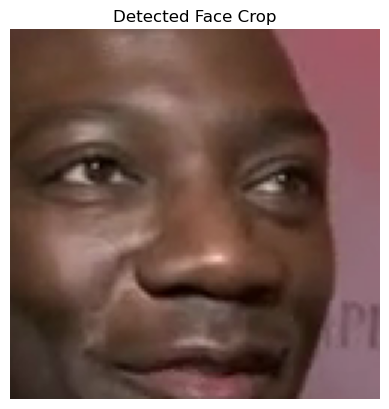

In [25]:
# Visually confirm by saving the detected face crop as an imageimport matplotlib.py
plot as plt                                        # matplotlib.pyplot — lets us display images directly in the notebook

if len(faces) > 0:                                                     # if len(faces) > 0 — only proceed if at least one face was actually found
    x, y, w, h = faces[0]                                               # x, y, w, h — unpack the first detected face's bounding box coordinates
    face_crop = frame[y:y+h, x:x+w]                                     # frame[y:y+h, x:x+w] — slices out just the face region from the full frame using those coordinates
    face_crop_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)          # cvtColor BGR2RGB — OpenCV loads colors in BGR order, but matplotlib expects RGB, so we convert for correct display
    
    plt.imshow(face_crop_rgb)                                          # imshow — displays the cropped face image inline in the notebook
    plt.title("Detected Face Crop")                                    # title — labels the plot for clarity
    plt.axis('off')                                                    # axis('off') — hides the pixel-coordinate axes, since they're not useful here
    plt.show()                                                          # show — actually renders the plot in the notebook output
else:
    print("No face detected in this frame — we'll need to handle this case in our full pipeline")  # fallback message if detection failed on this particular frame

In [26]:
# Define the full per-clip processing function
N_FRAMES_PER_CLIP = 5  # N_FRAMES_PER_CLIP — how many frames we'll sample evenly from each video (5 gives temporal variety without extracting every single frame)

def extract_faces_from_video(video_path, output_dir, clip_id, n_frames=N_FRAMES_PER_CLIP):
    # extract_faces_from_video — our reusable function: takes one video, returns how many faces it successfully saved
    cap = cv2.VideoCapture(video_path)                                      # VideoCapture — opens the video file for reading
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))                   # CAP_PROP_FRAME_COUNT — total number of frames in this video

    if total_frames <= 0:                                                   # if total_frames <= 0 — guards against corrupt/unreadable videos
        cap.release()                                                       # release — close the file since we're bailing out early
        return 0                                                            # return 0 — signal that zero faces were saved for this clip

    frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)   # linspace — picks n_frames evenly spaced frame numbers across the whole video (e.g., start, ~25%, ~50%, ~75%, end)

    saved_count = 0                                                         # saved_count — tracks how many face crops we successfully saved for this clip
    for i, frame_idx in enumerate(frame_indices):                          # enumerate — loops through our chosen frame indices, i is just a counter (0,1,2...)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)                         # CAP_PROP_POS_FRAMES — jumps the video reader to this specific frame number
        ret, frame = cap.read()                                            # read() — actually grabs that frame; ret confirms success

        if not ret:                                                         # if not ret — skip this frame if it failed to read (corrupt frame)
            continue                                                        # continue — move on to the next frame index in the loop

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)                      # cvtColor — convert to grayscale, required by our face detector
        faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)  # detectMultiScale — run face detection on this frame

        if len(faces) > 0:                                                  # if len(faces) > 0 — only save if a face was actually found
            x, y, w, h = faces[0]                                          # faces[0] — take the first detected face (assumes one main subject per clip)
            face_crop = frame[y:y+h, x:x+w]                                # frame[y:y+h, x:x+w] — crop just the face region out of the full frame
            face_crop = cv2.resize(face_crop, (224, 224))                  # resize — standardize every face crop to 224x224 pixels, a common size for feeding into deep learning models later

            out_path = output_dir / f"{clip_id}_frame{i}.jpg"              # out_path — builds a unique filename per clip and frame number
            cv2.imwrite(str(out_path), face_crop)                          # imwrite — saves the cropped face image to disk as a .jpg file
            saved_count += 1                                               # saved_count += 1 — increment our success counter

    cap.release()                                                          # release — close the video file now that we're done with it
    return saved_count                                                     # return saved_count — report back how many faces we successfully saved for this clip

print("Function defined")                                                  # print — simple confirmation the function was created without error

Function defined


In [27]:
# Run face extraction on the full subset
results = []  # results — an empty list where we'll record how each clip was processed, for later analysis

for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Extracting faces"):
    # iterrows() — loops through subset_df one row at a time; idx is the row number, row is the row's data
    # tqdm(...) — wraps the loop to show a live progress bar since this processes 2000 clips
    video_path = "../data/raw/" + row['zip_path']                          # video_path — builds the full local path to this clip's video file
    clip_id = f"{idx}_{row['type']}"                                       # clip_id — a unique identifier combining the row number and category, used to name saved files

    n_saved = extract_faces_from_video(video_path, frames_dir, clip_id)    # extract_faces_from_video — calls our function from Cell 7 on this one clip

    results.append({                                                       # append — adds a record of this clip's outcome to our results list
        'index': idx,                                                      # index — which row this was, so we can trace back to subset_df later
        'type': row['type'],                                              # type — the label (RealVideo-RealAudio, etc.), carried through for reference
        'clip_id': clip_id,                                                # clip_id — same unique ID used in the saved filenames
        'faces_saved': n_saved                                            # faces_saved — how many face crops were successfully extracted (0 to N_FRAMES_PER_CLIP)
    })

results_df = pd.DataFrame(results)                                         # DataFrame — converts our list of results into a proper table for easy analysis

print(f"Clips with 0 faces detected: {(results_df['faces_saved'] == 0).sum()}")           # sum() — counts how many clips had zero successful face extractions (potential problem clips)
print(f"Total face images saved: {results_df['faces_saved'].sum()}")                       # sum() — total count of all face images saved across every clip
print(f"Average faces per clip: {results_df['faces_saved'].mean():.2f}")                   # mean() — average number of faces saved per clip (out of a max of 5)

Extracting faces: 100%|███████████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:59<00:00, 16.70it/s]

Clips with 0 faces detected: 50
Total face images saved: 8772
Average faces per clip: 4.39


In [28]:
# Inspect the clips with zero faces detected
zero_face_clips = results_df[results_df['faces_saved'] == 0]                # results_df[...] — filters our results table down to only the rows where faces_saved equals 0

print(f"Number of clips with 0 faces: {len(zero_face_clips)}")              # print — confirms the count matches what we saw above
print("\nBreakdown by type:")                                               # print — a header for the next line
print(zero_face_clips['type'].value_counts())                               # value_counts() — shows how these 50 failures are distributed across our 4 categories (important: if failures cluster in one category, that's a bias risk)

Number of clips with 0 faces: 50

Breakdown by type:
type
RealVideo-FakeAudio    16
RealVideo-RealAudio    15
FakeVideo-FakeAudio    12
FakeVideo-RealAudio     7
Name: count, dtype: int64


In [29]:
# Drop the 50 problem clips and finalize our clean subset
clean_subset_df = subset_df[~subset_df.index.isin(zero_face_clips['index'])].copy()  # ~subset_df.index.isin(...) — keeps only rows whose index is NOT in our zero_face_clips list; .copy() avoids a pandas warning about modifying a filtered view

print(f"Clean subset size: {len(clean_subset_df)}")                                   # print — should be 2000 - 50 = 1950
print(clean_subset_df['type'].value_counts())                                         # value_counts() — confirms the new counts per category after dropping the 50

Clean subset size: 1950
type
FakeVideo-RealAudio    493
FakeVideo-FakeAudio    488
RealVideo-RealAudio    485
RealVideo-FakeAudio    484
Name: count, dtype: int64


In [30]:
# Define the audio extraction function
def extract_audio_from_video(video_path, output_dir, clip_id):
    # extract_audio_from_video — our reusable function: takes one video, saves its audio track, returns True/False for success
    try:                                                                    # try — lets us attempt this and gracefully handle any failure (some clips may have no audio track at all)
        video = VideoFileClip(video_path)                                  # VideoFileClip — opens the video file using moviepy, which can access both video and audio streams
        audio = video.audio                                                # video.audio — extracts just the audio portion of the clip

        if audio is None:                                                  # if audio is None — some videos genuinely have no audio track
            video.close()                                                  # close — releases the video file's resources
            return False                                                   # return False — signal that audio extraction failed for this clip

        out_path = output_dir / f"{clip_id}.wav"                          # out_path — builds the output filename for this clip's audio
        audio.write_audiofile(str(out_path), logger=None)                 # write_audiofile — saves the audio as a .wav file; logger=None silences moviepy's verbose per-file printout

        video.close()                                                      # close — releases the video file's resources now that we're done
        return True                                                        # return True — signal successful extraction

    except Exception as e:                                                 # except Exception as e — catches ANY error (corrupt file, codec issue, etc.) so one bad clip doesn't crash our whole loop
        return False                                                       # return False — treat any error as a failed extraction for this clip

print("Audio function defined")                                            # print — confirms the function was created without error

Audio function defined


In [31]:
# Run audio extraction on the full clean subset
audio_results = []  # audio_results — an empty list where we'll record each clip's audio extraction outcome

for idx, row in tqdm(clean_subset_df.iterrows(), total=len(clean_subset_df), desc="Extracting audio"):
    # iterrows() — loops through clean_subset_df one row at a time
    # tqdm(...) — shows a live progress bar for this 1950-clip loop
    video_path = "../data/raw/" + row['zip_path']                          # video_path — full local path to this clip's video file
    clip_id = f"{idx}_{row['type']}"                                       # clip_id — same unique ID convention we used for face crops, so audio/face files can be matched later

    success = extract_audio_from_video(video_path, audio_dir, clip_id)     # extract_audio_from_video — calls our Cell 11 function on this one clip

    audio_results.append({                                                 # append — records this clip's outcome
        'index': idx,                                                      # index — row number, to trace back to clean_subset_df
        'type': row['type'],                                              # type — the category label, carried through
        'clip_id': clip_id,                                                # clip_id — matches the saved .wav filename
        'audio_extracted': success                                        # audio_extracted — True/False, whether this clip's audio saved successfully
    })

audio_results_df = pd.DataFrame(audio_results)                             # DataFrame — converts our results list into a table

print(f"Successful audio extractions: {audio_results_df['audio_extracted'].sum()} / {len(audio_results_df)}")  # sum() on booleans — counts how many True values, i.e. successes
print(f"\nFailures by type:")                                              # print — header for the next line
print(audio_results_df[~audio_results_df['audio_extracted']]['type'].value_counts())  # ~audio_extracted — filters to only failures, then breaks them down by category

Extracting audio: 100%|███████████████████████████████████████████████████████████████████████████████████| 1950/1950 [09:59<00:00,  3.25it/s]

Successful audio extractions: 1950 / 1950

Failures by type:
Series([], Name: count, dtype: int64)


In [32]:
# Build the final merged dataset table
results_df_indexed = results_df.set_index('index')                          # set_index — makes 'index' the row label so we can align it with clean_subset_df by matching row numbers

final_df = clean_subset_df.copy()                                           # copy() — start from our clean 1950-row subset, so we don't accidentally modify the original
final_df['clip_id'] = final_df.index.map(lambda i: f"{i}_{final_df.loc[i, 'type']}")  # map — rebuilds the same clip_id string for every row, matching what we used when saving files

final_df['faces_saved'] = final_df.index.map(results_df_indexed['faces_saved'])  # map — pulls in how many face crops were saved for each clip, matched by row index

final_df['audio_extracted'] = True                                          # audio_extracted — we already know all 1950 succeeded, so we can just set this directly instead of merging

final_df['face_dir'] = str(frames_dir)                                      # face_dir — records where the face images live, so future code knows where to look
final_df['audio_path'] = final_df['clip_id'].apply(lambda cid: str(audio_dir / f"{cid}.wav"))  # audio_path — builds the exact path to each clip's saved .wav file

print(final_df.shape)                                                       # shape — should be (1950, however many columns we now have)
final_df[['type', 'clip_id', 'faces_saved', 'audio_extracted', 'audio_path']].head(10)  # head(10) — preview the key new columns to sanity check everything lined up correctly

(1950, 17)


,type,clip_id,faces_saved,audio_extracted,audio_path
0,RealVideo-RealAudio,0_RealVideo-RealAudio,3,True,../data/processed/audio/0_RealVideo-RealAudio.wav
1,RealVideo-RealAudio,1_RealVideo-RealAudio,3,True,../data/processed/audio/1_RealVideo-RealAudio.wav
2,RealVideo-RealAudio,2_RealVideo-RealAudio,5,True,../data/processed/audio/2_RealVideo-RealAudio.wav
3,RealVideo-RealAudio,3_RealVideo-RealAudio,2,True,../data/processed/audio/3_RealVideo-RealAudio.wav
4,RealVideo-RealAudio,4_RealVideo-RealAudio,4,True,../data/processed/audio/4_RealVideo-RealAudio.wav
5,RealVideo-RealAudio,5_RealVideo-RealAudio,1,True,../data/processed/audio/5_RealVideo-RealAudio.wav
6,RealVideo-RealAudio,6_RealVideo-RealAudio,5,True,../data/processed/audio/6_RealVideo-RealAudio.wav
7,RealVideo-RealAudio,7_RealVideo-RealAudio,1,True,../data/processed/audio/7_RealVideo-RealAudio.wav
8,RealVideo-RealAudio,8_RealVideo-RealAudio,4,True,../data/processed/audio/8_RealVideo-RealAudio.wav
9,RealVideo-RealAudio,9_RealVideo-RealAudio,2,True,../data/processed/audio/9_RealVideo-RealAudio.wav


In [33]:
# Save this as our final Scrub output
final_df.to_csv("../data/processed/scrubbed_dataset.csv", index=False)     # to_csv — saves our final merged table to disk, this becomes THE reference file for Explore and Model
print("Saved scrubbed_dataset.csv")                                        # print — confirmation
print(f"Final dataset: {len(final_df)} clips, {final_df['faces_saved'].sum()} face images, {final_df['audio_extracted'].sum()} audio files")  # print — a one-line summary of everything Scrub produced

Saved scrubbed_dataset.csv
Final dataset: 1950 clips, 8772 face images, 1950 audio files
